The following code follows experimenting with the raw_output cryptocoin data generated from CoinMarketCap in order to empirically justify a column metric to track, as well as the hyperparameters for that tracking, namely the number of data points to track before computing anomalies and the z-score threshold for a record to be considered anomalous.

In [2]:
import os
import pandas as pd

In [ ]:
raw_data_path = 'output/raw_output/'
csv_paths = []
for folder_name in os.listdir(raw_data_path):
    if 'event_dt' not in folder_name:
        continue

    event_dt_path = os.path.join(raw_data_path, folder_name)
    with os.scandir(event_dt_path) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.endswith('csv'):
                csv_paths.append(os.path.join(event_dt_path, entry.name))

['output/raw_output/event_dt=2026-04-15/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-08/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-18/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-16/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-14/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-20/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-07/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-17/part-00000-e29d7066-f6c9-4165-b4a0-a54ee3e70334.c000.csv', 'output/raw_output/event_dt=2026-04-21/part-00000-21f7df21-5e68-4825-adc9-eb42addedf67.c000.csv', 'output/raw_output/event_dt=2026-04-21/part-00000-4abe7e57-a7af-4678-9968-bdbc6b70d4bb.c000.csv', 'output/raw_output/

In [49]:
df = None
for csv_path in csv_paths:
    if df is None:
        df = pd.read_csv(csv_path)
    else:
        df = pd.concat([df, pd.read_csv(csv_path)], ignore_index=True)
df['event_ts'] = pd.to_datetime(df['event_ts'], utc=True)

df = df.sort_values(['id', 'event_ts']).reset_index(drop=True)
df.head(72)


,id,name,symbol,price,event_ts,volume_24h,volume_change_24h,percent_change_1h,percent_change_24h,processing_time,event_id
0,1,Bitcoin,BTC,72180.154089,2026-04-07 23:51:00+00:00,4.437574e+10,11.8341,1.602921,4.881272,2026-04-21T03:59:41.837Z,36c8a0b4f893bff61198f38608f0bb25f3fdc43e653f58...
1,1,Bitcoin,BTC,71987.946937,2026-04-07 23:56:00+00:00,4.460529e+10,12.7439,1.084607,4.491615,2026-04-21T03:59:41.837Z,3fe5813a38bce8532b9de4ae7a766a3637f88be5e7f9c3...
2,1,Bitcoin,BTC,71939.685898,2026-04-08 00:02:00+00:00,4.458782e+10,13.6079,0.570678,4.431077,2026-04-21T03:59:41.837Z,2cdcfa886c10507d054dd53e09670b57183d49c80a01db...
3,1,Bitcoin,BTC,71430.298835,2026-04-08 02:21:00+00:00,4.630097e+10,24.2310,-0.130125,4.228847,2026-04-21T03:59:41.837Z,1d6b60fe6aebb2973902efba7c1200967398ef6df2888c...
4,1,Bitcoin,BTC,71448.367750,2026-04-08 02:26:00+00:00,4.589235e+10,23.4746,-0.135073,4.223259,2026-04-21T03:59:41.837Z,614ee226b51c15d0de1b6c89e9d996a30a6c45291db050...
...,...,...,...,...,...,...,...,...,...,...,...
67,1,Bitcoin,BTC,74550.915806,2026-04-15 00:42:00+00:00,5.295430e+10,-0.3486,0.501502,0.205221,2026-04-21T03:59:41.837Z,bebc57fca48ec60d21b3244267f1c797b1aed10b064f3f...
68,1,Bitcoin,BTC,74599.046741,2026-04-15 00:46:00+00:00,5.306090e+10,-0.2746,0.561417,0.228310,2026-04-21T03:59:41.837Z,e8910ec43b7baa5a08133d39b282dd013fa47bf97c4731...
69,1,Bitcoin,BTC,74539.941633,2026-04-15 00:52:00+00:00,5.275054e+10,1.2444,0.456321,0.472542,2026-04-21T03:59:41.837Z,2ac71300ee44497e306c7df0aec000a4a97a98ca93df4f...
70,1,Bitcoin,BTC,74494.627548,2026-04-15 00:56:00+00:00,5.291301e+10,1.2119,0.533043,0.424422,2026-04-21T03:59:41.837Z,098f98bc2db8e5be8640a7daadf4311f1a493a5a00c8ee...


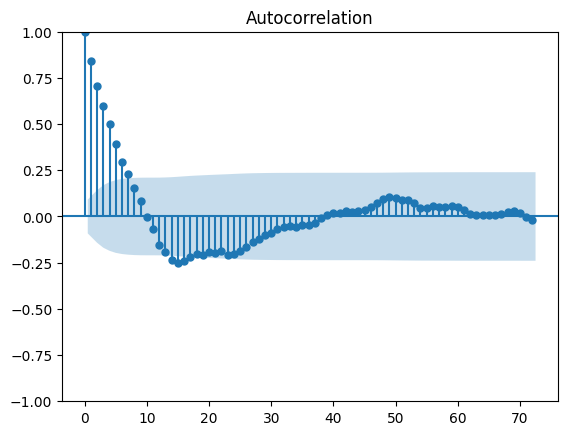

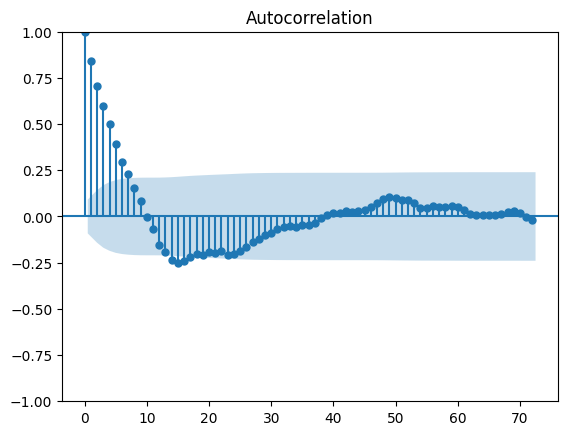

In [60]:
from statsmodels.graphics.tsaplots import plot_acf
# plot_acf(df[df['symbol'] == 'BTC']['price'], lags=72)  # 72 = 6hrs of 5min intervals
plot_acf(df[df['symbol'] == 'BTC']['percent_change_1h'], lags=72)  # 72 = 6hrs of 5min intervals
# plot_acf(df[df['symbol'] == 'ETH']['percent_change_1h'], lags=72)  # 72 = 6hrs of 5min intervals

In [56]:
for w in [6, 12, 18, 36, 72]:  # windows in # of 5min intervals
    df[f'vol_{w}'] = df.groupby('id')['percent_change_1h'].transform(
        lambda x: x.rolling(w).std()
    )

window = 12  # your chosen 60-min window

df['rolling_mean'] = df.groupby('id')['percent_change_1h'].transform(
    lambda x: x.rolling(window).mean()
)
df['rolling_std'] = df.groupby('id')['percent_change_1h'].transform(
    lambda x: x.rolling(window).std()
)
df['zscore'] = (df['percent_change_1h'] - df['rolling_mean']) / df['rolling_std']
# Keeps rows with at least 2 non-NaN values
# df_filtered = df[df['vol_6'].notna() & df['vol_12'].notna() & df['vol_18'] & df['vol_36']]
# df_filtered.sort_values('id').head(50)

In [57]:
for t in [2.0, 2.5, 3.0, 3.5]:
    rate = (df['zscore'].abs() > t).mean()
    print(f"Threshold {t}: {rate:.2%} of records flagged")

Threshold 2.0: 7.85% of records flagged
Threshold 2.5: 1.33% of records flagged
Threshold 3.0: 0.07% of records flagged
Threshold 3.5: 0.00% of records flagged


Kurtosis: -0.94


<Axes: >

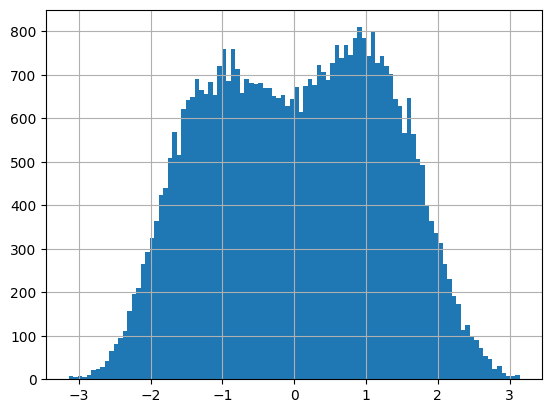

In [58]:
from scipy import stats
z = df['zscore'].dropna()
print(f"Kurtosis: {stats.kurtosis(z):.2f}")  # >3 means fat tails
z.hist(bins=100)